In [1]:
import tensorflow as tf
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

In [2]:
# CONFIGURATION
PROCESSED_DATA_DIR = 'brain_tumor_data_preprocessed/'
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 100
LEARNING_RATE = 0.0001

In [3]:
augment = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [4]:
def zscore(x):
    x = tf.image.convert_image_dtype(x, tf.float32)
    m = tf.reduce_mean(x, axis=[1,2,3], keepdims=True)
    s = tf.math.reduce_std(x,  axis=[1,2,3], keepdims=True) + 1e-6
    return (x - m) / s

def map_train(x, y): 
    x = zscore(x)
    return (augment(x, training=True), y)
    
def map_eval(x, y):  
    return (zscore(x), y)

In [5]:
# DATA LOADING / AUGMENTATION using TensorFlow
train_data = keras.utils.image_dataset_from_directory(
    PROCESSED_DATA_DIR,
    labels="inferred",
    label_mode="binary",
    color_mode="grayscale",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="training",
    seed=42,
    shuffle=True,
)
validation_data = keras.utils.image_dataset_from_directory(
    PROCESSED_DATA_DIR,
    labels="inferred",
    label_mode="binary",
    color_mode="grayscale",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="validation",
    seed=24,
    shuffle=True,
)
AUTOTUNE = tf.data.AUTOTUNE
train_data = train_data.cache().prefetch(AUTOTUNE)
validation_data   = validation_data.cache().prefetch(AUTOTUNE)

train_data = train_data.map(map_train, num_parallel_calls=AUTOTUNE)
validation_data   = validation_data.map(map_eval,  num_parallel_calls=AUTOTUNE)

Found 205 files belonging to 2 classes.
Using 164 files for training.
Found 205 files belonging to 2 classes.
Using 41 files for validation.


In [6]:
# Architecture References: 
# https://www.codecademy.com/article/understanding-convolutional-neural-network-cnn-architecture
# https://developers.google.com/machine-learning/practica/image-classification/convolutional-neural-networks

In [7]:
class NeuroScanCNN(tf.keras.Model):
    def __init__(self):
        super(NeuroScanCNN, self).__init__()
        l2 = keras.regularizers.l2(1e-5)
        self.norm_1 = layers.BatchNormalization()
        self.convolutional_1 = layers.Conv2D(32,
                                             (3,3),
                                             padding='same',
                                             activation="relu", 
                                             kernel_regularizer=l2,
                                            input_shape=(224, 224, 1))
        self.norm_1 = layers.BatchNormalization()
        self.pooling_1 = layers.MaxPool2D((2,2))

        self.convolutional_2 = layers.Conv2D(64, 
                                             (3,3), 
                                             padding='same',
                                             activation='relu',
                                             kernel_regularizer=l2)
        self.norm_2 = layers.BatchNormalization()
        self.pooling_2 = layers.MaxPool2D((2,2))

        self.convolutional_3 = layers.Conv2D(128, 
                                             (3,3), 
                                             padding='same',
                                             activation='relu',
                                             kernel_regularizer=l2)
        self.norm_3 = layers.BatchNormalization()
        self.pooling_3 = layers.MaxPool2D((2,2))

        # Classification layer
        self.flatten = layers.Flatten()
        self.dense = layers.Dense(128, 
                                  activation='relu',
                                  kernel_regularizer=l2)
        self.dropout = layers.Dropout(0.4) # More overfitting protection
        
        # Setting sigmoid for 0/1 output Note: Cannot use "output" in __init__
        self.output_layer = layers.Dense(1, activation='sigmoid') 

    def call(self, inputs, training=False):
        conv_x = self.convolutional_1(inputs)
        conv_x = self.norm_1(conv_x, training=training)
        pool_x = self.pooling_1(conv_x)

        conv_x = self.convolutional_2(pool_x)
        conv_x = self.norm_2(conv_x, training=training)
        pool_x = self.pooling_2(conv_x)

        conv_x = self.convolutional_3(pool_x)
        conv_x = self.norm_3(conv_x, training=training)
        pool_x = self.pooling_3(conv_x)

        flat_x = self.flatten(pool_x)
        dense_x = self.dense(flat_x)
        dense_x = self.dropout(dense_x, training=training)
        return self.output_layer(dense_x)  

In [8]:
# Create and compile model
model = NeuroScanCNN()
# Declare input size here for OO formatting
model.build(input_shape=(None, 224, 224, 1))
# Compiling with Binary Cross Entropy loss and accuracy as the main metric per README
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=['accuracy',
             keras.metrics.Precision(name="precision"),
             keras.metrics.Recall(name="recall"),
             keras.metrics.AUC(name="auc"),
             keras.metrics.TruePositives(name='tp'),
             keras.metrics.FalsePositives(name='fp'),
             keras.metrics.TrueNegatives(name='tn'),
             keras.metrics.FalseNegatives(name='fn'),]
)

C:\Users\nickb\miniconda3\envs\neuroscan\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\nickb\miniconda3\envs\neuroscan\Lib\site-packages\keras\src\layers\layer.py:421: UserWarning: `build()` was called on layer 'neuro_scan_cnn', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


In [9]:
# Callbacks
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_auc',
        patience=10,
        mode='max',
        restore_best_weights=True,
        start_from_epoch=50
    ),
    
    keras.callbacks.ModelCheckpoint(
        'neuroscan_model_checkpoint.keras',
        monitor='val_auc', # Using loss as the monitor
        mode='max',
        save_best_only=True
    ),
    
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        factor=0.5,
        mode='max',
        patience=5,
        min_lr=1e-7
    )
]

In [17]:
# Training
print("Starting training")
hist = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=EPOCHS,
    callbacks=callbacks
)
print("Finished training")

Starting training
Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 703ms/step - accuracy: 0.9573 - auc: 0.9929 - fn: 4.0000 - fp: 3.0000 - loss: 0.1428 - precision: 0.9703 - recall: 0.9608 - tn: 59.0000 - tp: 98.0000 - val_accuracy: 0.9512 - val_auc: 0.9947 - val_fn: 1.0000 - val_fp: 1.0000 - val_loss: 0.1785 - val_precision: 0.9630 - val_recall: 0.9630 - val_tn: 13.0000 - val_tp: 26.0000 - learning_rate: 3.1250e-06
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 698ms/step - accuracy: 0.9573 - auc: 0.9823 - fn: 2.0000 - fp: 5.0000 - loss: 0.1768 - precision: 0.9524 - recall: 0.9804 - tn: 57.0000 - tp: 100.0000 - val_accuracy: 0.9512 - val_auc: 0.9947 - val_fn: 1.0000 - val_fp: 1.0000 - val_loss: 0.1810 - val_precision: 0.9630 - val_recall: 0.9630 - val_tn: 13.0000 - val_tp: 26.0000 - learning_rate: 3.1250e-06
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 701ms/step - accuracy: 0.9390 - auc: 0.9933 - fn: 7.0000 - fp: 3.0000 - loss: 0.1551 - precision: 0.9694 - recall: 0.9314 - tn: 59.0000 - tp: 95.0000 - val

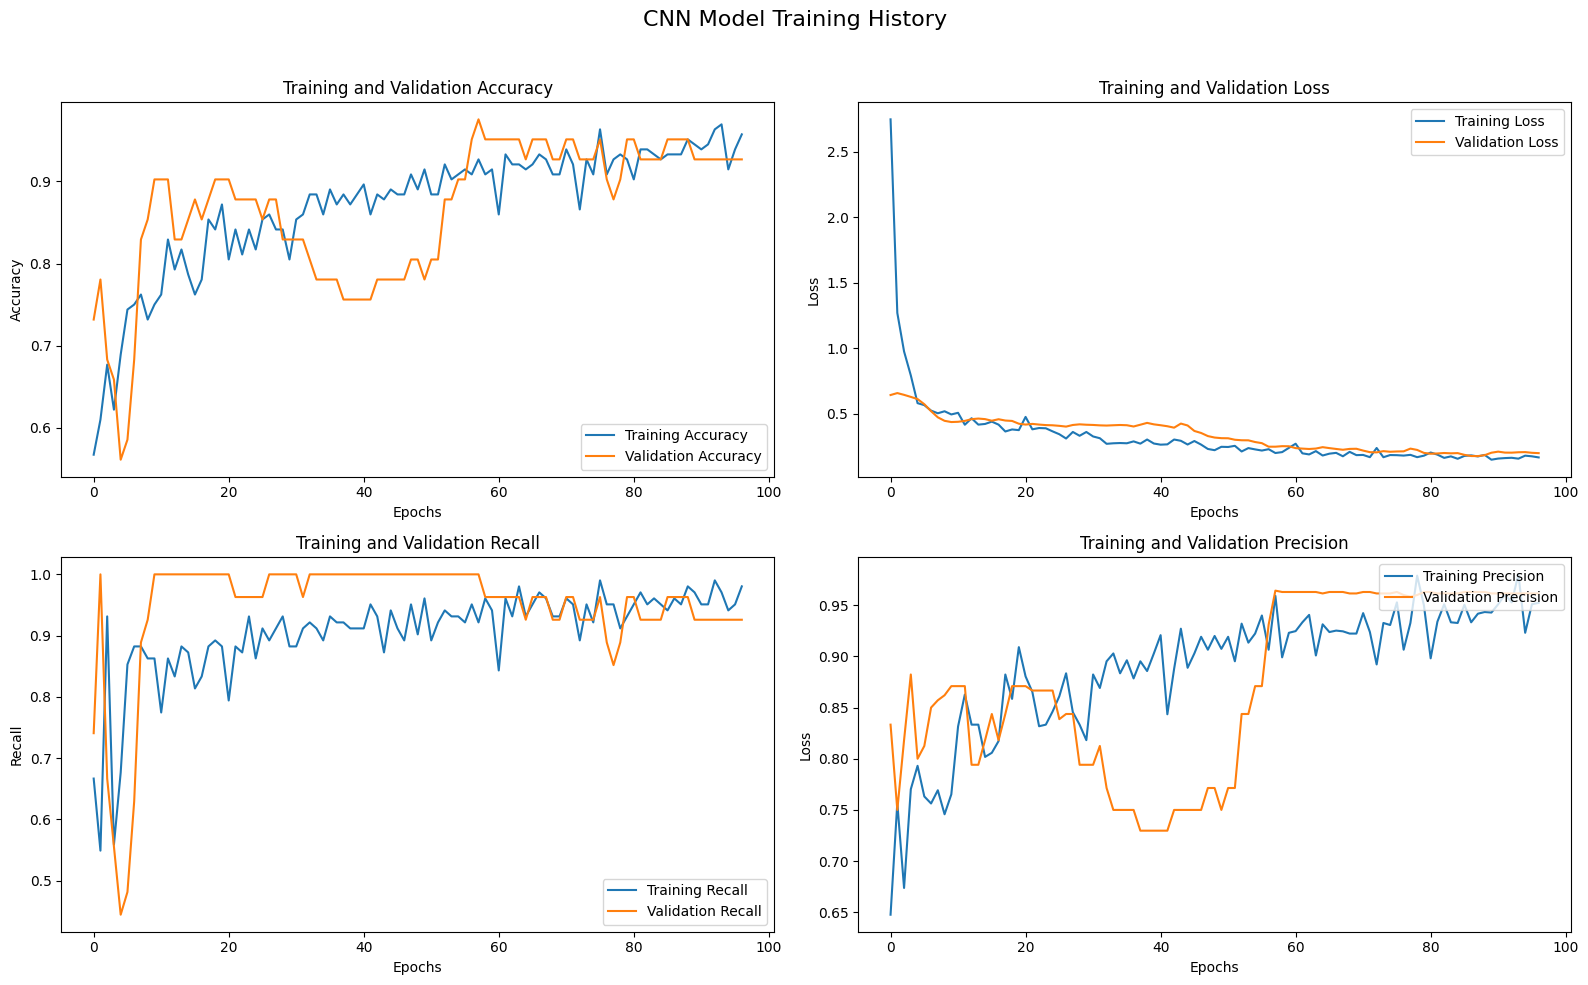

In [16]:
def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    recall = history.history['recall']
    val_recall = history.history['val_recall']
    precision = history.history['precision']
    val_precision = history.history['val_precision']
    
    epochs_range = range(len(acc))

    # Create a 2x2 grid of plots
    plt.figure(figsize=(16, 10))
    
    # Plot 1: Accuracy
    plt.subplot(2, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')

    # Plot 2: Loss
    plt.subplot(2, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')

    # Plot 3: Recall
    plt.subplot(2, 2, 3)
    plt.plot(epochs_range, recall, label='Training Recall')
    plt.plot(epochs_range, val_recall, label='Validation Recall')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Recall')
    plt.xlabel('Epochs')
    plt.ylabel('Recall')

    # Plot 4: Precision
    plt.subplot(2, 2, 4)
    plt.plot(epochs_range, precision, label='Training Precision')
    plt.plot(epochs_range, val_precision, label='Validation Precision')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Precision')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')

    plt.suptitle("CNN Model Training History", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

plot_training_history(hist)

In [14]:
results = model.evaluate(validation_data, verbose=0)

# Collect predictions and labels correctly
y_true_list = []
y_pred_list = []

print("Collecting predictions batch by batch...")
for batch_images, batch_labels in validation_data:
    batch_preds = model.predict(batch_images, verbose=0)
    y_pred_list.append(batch_preds)
    y_true_list.append(batch_labels.numpy())

# Concatenate all batches
y_true = np.concatenate(y_true_list).flatten()
y_pred_probs = np.concatenate(y_pred_list).flatten()
y_pred = (y_pred_probs > 0.5).astype(int)

print(f"Total validation samples collected: {len(y_true)}")
print(f"Should be: 41")

# Calculate confusion matrix
tp = np.sum((y_true == 1) & (y_pred == 1))
fp = np.sum((y_true == 0) & (y_pred == 1))
tn = np.sum((y_true == 0) & (y_pred == 0))
fn = np.sum((y_true == 1) & (y_pred == 0))

print(f"\nConfusion Matrix:")
print(f"True Positives: {tp}")
print(f"False Positives: {fp}")
print(f"True Negatives: {tn}")
print(f"False Negatives: {fn}")
print(f"Total: {tp + fp + tn + fn}")

# Label distribution check
print(f"\nLabel distribution:")
print(f"Positive samples (tumor): {np.sum(y_true == 1)}")
print(f"Negative samples (no tumor): {np.sum(y_true == 0)}")
print(f"Positive ratio: {np.mean(y_true):.2f}")

# Prediction distribution
print(f"\nPrediction distribution:")
print(f"Predicted positive: {np.sum(y_pred == 1)}")
print(f"Predicted negative: {np.sum(y_pred == 0)}")

# Show prediction probabilities distribution
print(f"\nPrediction probabilities stats:")
print(f"Min: {y_pred_probs.min():.4f}")
print(f"Max: {y_pred_probs.max():.4f}")
print(f"Mean: {y_pred_probs.mean():.4f}")
print(f"Median: {np.median(y_pred_probs):.4f}")

print(f"\nWith only 41 validation samples, even 1-2 FP/FN significantly impacts metrics")

Total validation samples collected: 41
Should be: 41

Confusion Matrix:
True Positives: 26
False Positives: 1
True Negatives: 13
False Negatives: 1
Total: 41

Label distribution:
Positive samples (tumor): 27
Negative samples (no tumor): 14
Positive ratio: 0.66

Prediction distribution:
Predicted positive: 27
Predicted negative: 14

Prediction probabilities stats:
Min: 0.0000
Max: 0.9999
Mean: 0.5775
Median: 0.6843

With only 41 validation samples, even 1-2 FP/FN significantly impacts metrics


In [15]:
model.summary()

Model: "neuro_scan_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ batch_normalization                  │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 224, 224, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 112, 112, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 56, 56, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 100352)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      12,845,184 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 38,815,749 (148.07 MB)

 Trainable params: 12,938,433 (49.36 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 25,876,868 (98.71 MB)